<a href="https://colab.research.google.com/github/betulkabakci/Uyku-Bozuklugu-Tahmini/blob/main/Bootcamp_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [4]:
from google.colab import files
import os

# Attempt to upload the file
uploaded = files.upload()

# Verify if the file was uploaded
file_name = 'Sleep_health_and_lifestyle_dataset.csv'
if file_name in uploaded.keys():
    print(f'File "{file_name}" uploaded successfully.')
else:
    print(f'Warning: "{file_name}" was not uploaded. Please ensure you select the correct file.')


Saving Sleep_health_and_lifestyle_dataset.csv to Sleep_health_and_lifestyle_dataset.csv
File "Sleep_health_and_lifestyle_dataset.csv" uploaded successfully.


In [7]:

# 1. Veri Setini Yükleme
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

# İlk gözlem
print("Veri Seti Boyutu:", df.shape)

Veri Seti Boyutu: (374, 13)


In [8]:
# 2. Veri Ön İşleme (Data Preprocessing)
# 'Sleep Disorder' sütunundaki boşluklar (NaN) aslında uyku bozukluğu olmadığını gösterir.
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

# Blood Pressure sütununu 'Systolic' ve 'Diastolic' olarak ikiye bölelim
df[["Systolic_BP", "Diastolic_BP"]] = df["Blood Pressure"].str.split(
    "/", expand=True
)
df["Systolic_BP"] = df["Systolic_BP"].astype(int)
df["Diastolic_BP"] = df["Diastolic_BP"].astype(int)
df = df.drop(
    columns=["Blood Pressure", "Person ID"]
)  # Gereksiz sütunları atalım

# Hedef değişkenimiz (Sleep Disorder) için etiketleme yapalım: 0 = Yok (None), 1 = Var (Insomnia / Sleep Apnea)
df["Target"] = df["Sleep Disorder"].apply(
    lambda x: 0 if x == "None" else 1
)  # İkili sınıflandırma (Binary Classification)

# Kategorik değişkenleri sayısal formata dönüştürme (Label Encoding)
label_encoders = {}
for col in ["Gender", "Occupation", "BMI Category"]:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  label_encoders[col] = le


In [9]:
# 3. Model Eğitimi İçin X ve y Ayrımı
X = df.drop(
    columns=["Sleep Disorder", "Target"]
)  # Model özellikleri (Features)
y = df["Target"]  # Hedef değişken (Target)

# Train-Test Ayrımı (%80 Eğitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Ölçeklendirme (Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# 4. Modellerin Eğitimi ve Değerlendirilmesi

# Model 1: Lojistik Regresyon (Baseline)
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

print("--- Lojistik Regresyon Sonuçları ---")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

# Model 2: Rastgele Orman (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

print("\n--- Random Forest Sonuçları ---")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

--- Lojistik Regresyon Sonuçları ---
Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.91      0.94      0.92        32

    accuracy                           0.93        75
   macro avg       0.93      0.93      0.93        75
weighted avg       0.93      0.93      0.93        75


--- Random Forest Sonuçları ---
Accuracy: 0.96
              precision    recall  f1-score   support

           0       0.95      0.98      0.97        43
           1       0.97      0.94      0.95        32

    accuracy                           0.96        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.96      0.96      0.96        75



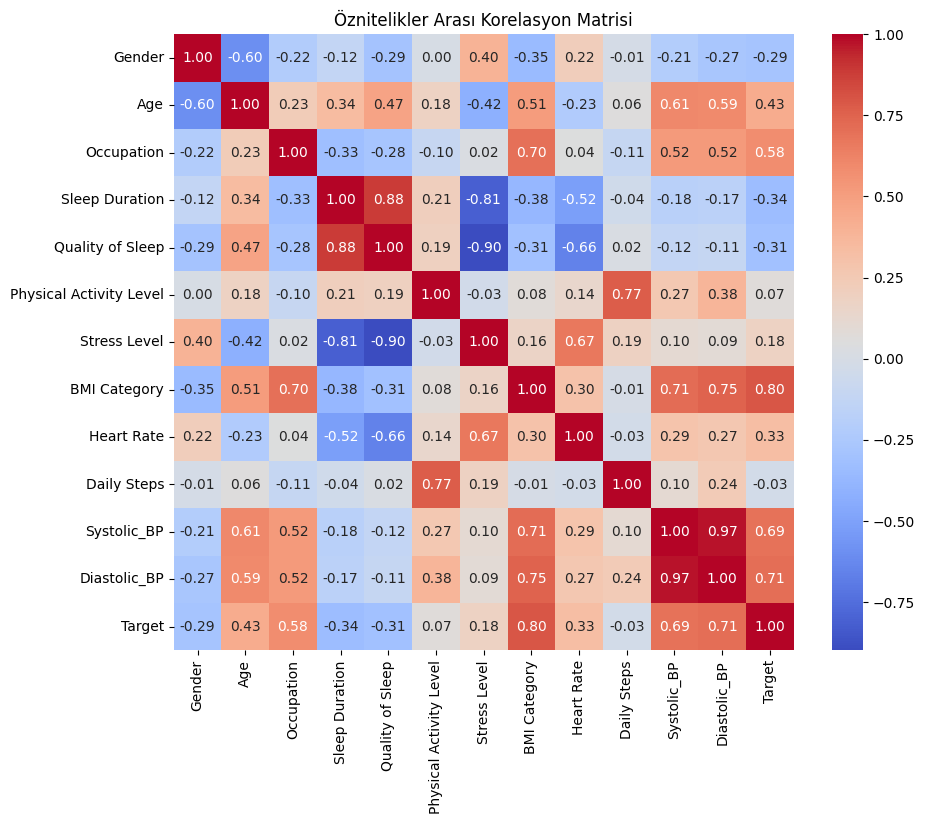

In [11]:
# Korelasyon Isı Haritası (Correlation Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.drop(columns=["Sleep Disorder"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("Öznitelikler Arası Korelasyon Matrisi")
plt.savefig("correlation_matrix.png")
plt.show()

/tmp/ipykernel_2764/637196690.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Stress Level", y="Quality of Sleep", data=df, palette="Set2")


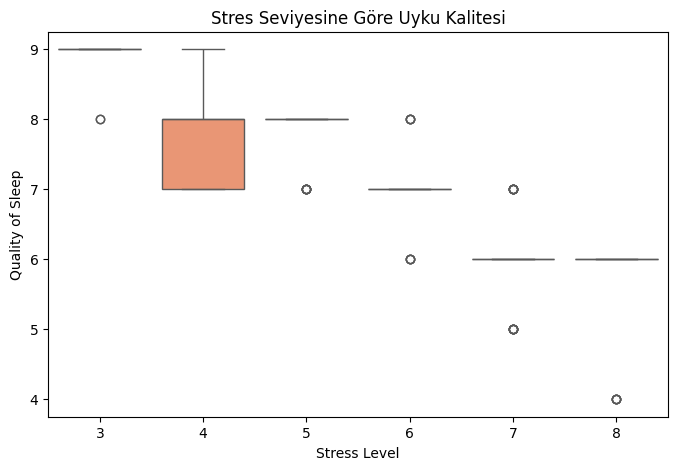

In [12]:
# Stres Seviyesi ve Uyku Kalitesi Dağılımı
plt.figure(figsize=(8, 5))
sns.boxplot(x="Stress Level", y="Quality of Sleep", data=df, palette="Set2")
plt.title("Stres Seviyesine Göre Uyku Kalitesi")
plt.savefig("stress_vs_sleep.png")
plt.show()